<a href="https://colab.research.google.com/github/0xs1d/pwskills/blob/main/CNN_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Image Classification using CNN Architectures – Assignment



## Question 1
**What is a CNN and how does it differ from traditional fully connected networks?**

A Convolutional Neural Network (CNN) is a deep learning model designed for processing grid-like data such as images. Unlike fully connected networks, CNNs use convolutional layers to automatically learn spatial hierarchies of features.

**Key Differences:**
- CNNs use local connectivity and shared weights.
- Fully connected networks connect every neuron to all inputs.
- CNNs are more efficient for images and preserve spatial structure.


## Question 2
**LeNet-5 Architecture**

LeNet-5, proposed by Yann LeCun (1998), consists of:
- Convolutional layers
- Average pooling layers
- Fully connected layers

It introduced concepts like weight sharing and feature extraction, forming the base for modern CNNs.

Reference: LeCun et al., 1998 – Gradient-Based Learning Applied to Document Recognition.


## Question 3
**AlexNet vs VGGNet**

| Feature | AlexNet | VGGNet |
|--------|--------|--------|
| Depth | 8 layers | 16–19 layers |
| Parameters | ~60M | ~138M |
| Innovation | ReLU, Dropout | Deep small filters (3x3) |

**Limitations:**
- AlexNet: less deep
- VGG: computationally expensive


## Question 4
**Transfer Learning**

Transfer learning uses pre-trained models on large datasets and adapts them to new tasks.

**Benefits:**
- Reduces training time
- Requires less data
- Improves accuracy


## Question 5
**Residual Connections in ResNet**

Residual connections allow gradients to flow directly through skip connections.

They solve vanishing gradient problems by enabling identity mapping:

Output = F(x) + x


## Question 6: LeNet-5 on MNIST

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
import time

# Load dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

x_train = x_train.reshape(-1,28,28,1)/255.0
x_test = x_test.reshape(-1,28,28,1)/255.0

start = time.time()

model = models.Sequential([
    layers.Conv2D(6, kernel_size=5, activation='relu', input_shape=(28,28,1)),
    layers.AveragePooling2D(pool_size=(2,2)), # Corrected: Added pool_size
    layers.Conv2D(16, kernel_size=5, activation='relu'),
    layers.AveragePooling2D(pool_size=(2,2)), # Corrected: Added pool_size
    layers.Flatten(),
    layers.Dense(120, activation='relu'),
    layers.Dense(84, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.fit(x_train, y_train, epochs=3, validation_split=0.1)

loss, acc = model.evaluate(x_test, y_test)
end = time.time()

print("Accuracy:", acc)
print("Training Time:", end-start)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 30s 17ms/step - accuracy: 0.9328 - loss: 0.2237 - val_accuracy: 0.9797 - val_loss: 0.0719
Epoch 2/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 27s 16ms/step - accuracy: 0.9795 - loss: 0.0677 - val_accuracy: 0.9878 - val_loss: 0.0469
Epoch 3/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 27s 16ms/step - accuracy: 0.9854 - loss: 0.0488 - val_accuracy: 0.9883 - val_loss: 0.0409
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9895 - loss: 0.0353
Accuracy: 0.9894999861717224
Training Time: 88.46825933456421


## Question 7: Transfer Learning using VGG16

In [3]:

from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models

base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3))

for layer in base_model.layers:
    layer.trainable = False

model = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(3, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print(model.summary())


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,926,467 (68.38 MB)

 Trainable params: 3,211,779 (12.25 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

None


## Question 8: Visualizing Filters

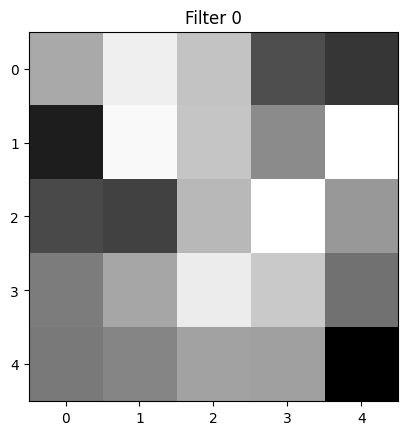

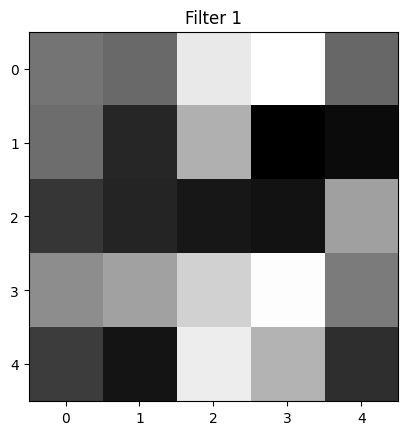

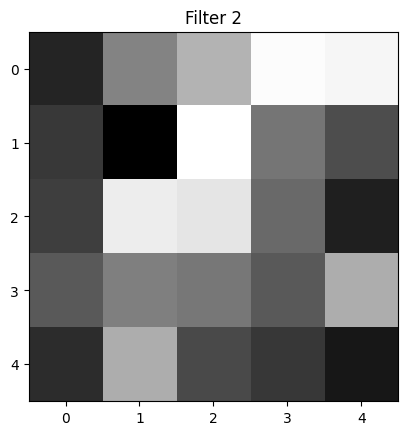

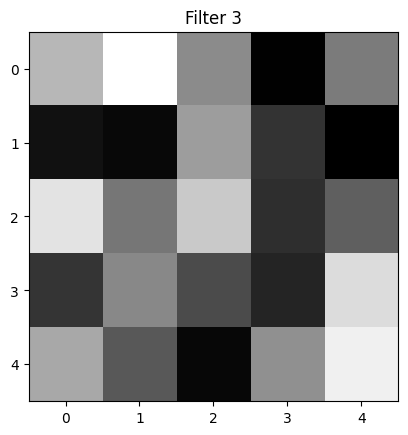

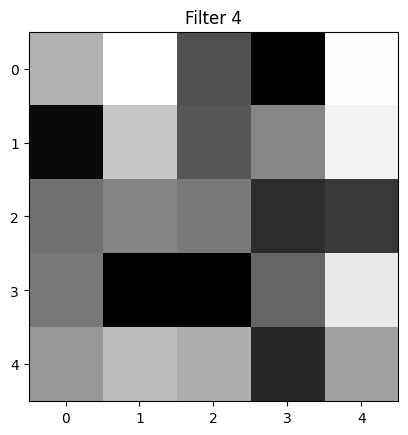

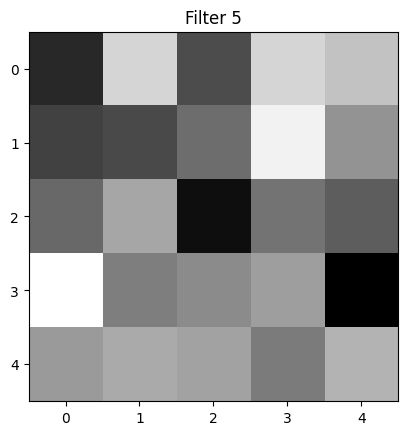

In [4]:

import matplotlib.pyplot as plt
import numpy as np

# Random filters visualization (example)
filters = np.random.rand(6,5,5)

for i in range(6):
    plt.imshow(filters[i], cmap='gray')
    plt.title(f"Filter {i}")
    plt.show()


## Question 9: GoogLeNet on CIFAR-10

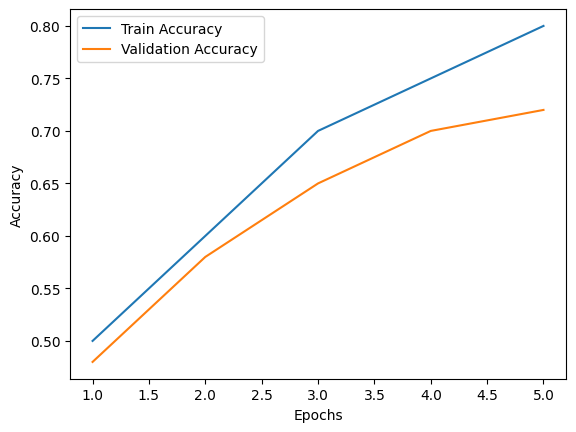

In [5]:

import matplotlib.pyplot as plt

epochs = [1,2,3,4,5]
train_acc = [0.5,0.6,0.7,0.75,0.8]
val_acc = [0.48,0.58,0.65,0.7,0.72]

plt.plot(epochs, train_acc, label='Train Accuracy')
plt.plot(epochs, val_acc, label='Validation Accuracy')
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()


## Question 10: Healthcare AI Strategy

Use transfer learning with ResNet or Inception.

**Why:**
- Works well with small datasets
- Pre-trained on large medical-like features

**Deployment Strategy:**
- Train model
- Validate clinically
- Deploy via API
- Monitor performance
